# Agriculture — crop water demand and soil moisture

Agroclimatic studies typically pair **inputs** (precipitation,
irrigation potential), **demand** (reference evapotranspiration
$ET_0$), and **soil status** (root-zone moisture). ERA5-Land carries
all three at 0.1° resolution — finer than the standard ERA5 product
and tuned for land-surface processes.

**Domain context.** A simplified agronomic water balance for a
rain-fed field over one growing season:

$$ \text{deficit}(t) = \sum (P - |ET|)_t $$

When the cumulative deficit is negative, the crop is drawing on
stored soil moisture; when positive, soil moisture should be
recharging. Pairing the deficit time series with `soil_moisture_layer_1`
(top 7 cm) gives an immediate visual check on the model's coupling.

## Step 1 — confirm the variables and their flux flags

Soil moisture is a **state** field (volumetric water content,
instantaneous). Precipitation and evaporation are **flux** fields
(per-step accumulations). `op="auto"` routes each correctly without
the user picking.

In [1]:
from earthly.ecmwf import Catalog

cat = Catalog()
for code in (
    "total-precipitation",
    "total-evaporation",
    "2m-temperature",
    "volumetric-soil-water-layer-1",
):
    spec = cat.get_variable("reanalysis-era5-land", code)
    print(
        f"{code:35s}  nc={spec.nc_variable:6s}  units={spec.units:25s}  is_flux={spec.is_flux}"
    )

total-precipitation                  nc=tp      units=m                          is_flux=True
total-evaporation                    nc=e       units=m of water equivalent      is_flux=True
2m-temperature                       nc=t2m     units=K                          is_flux=False
volumetric-soil-water-layer-1        nc=swvl1   units=m**3 m**-3                 is_flux=False


## Step 2 — retrieve a growing season at monthly resolution

Box: a ~1° area in the central US corn belt (40°–41°N, 92°–91°W).
Range: May–October 2022 — the heart of the corn-belt growing
season. ERA5-Land's monthly-means product gives one value per
month at 0.1° native grid. Mixed flux + state retrieve in one
call.

In [2]:
from pathlib import Path
from earthly import Earthly, AggregationConfig

OUT = Path("data/era5-land-corn-belt")
OUT.mkdir(parents=True, exist_ok=True)

earthly = Earthly(
    data_source="ecmwf",
    temporal_resolution="monthly",
    start="2022-05-01",
    end="2022-10-01",
    variables={
        "reanalysis-era5-land-monthly-means": [
            "total-precipitation",
            "total-evaporation",
            "2m-temperature",
            "volumetric-soil-water-layer-1",
        ],
    },
    lat_lim=[40.0, 41.0],
    lon_lim=[-92.0, -91.0],
    path=str(OUT),
)
earthly.download(aggregate=AggregationConfig(freq="1MS", op="auto", cell_size=0.1))

2026-05-10 01:36:59.419 | INFO     | earthly.ecmwf.backend:download:536 - Download ECMWF reanalysis-era5-land-monthly-means/total-precipitation data for period 2022-05-01 00:00:00 till 2022-10-01 00:00:00


2026-05-10 01:37:00.050 | INFO     | earthly.ecmwf.backend:_api:724 - Requesting reanalysis-era5-land-monthly-means from CDS; this may take several minutes


2026-05-10 01:37:00,301 INFO Request ID is b417de00-57e0-44e1-9e2f-5b684db0b115


2026-05-10 01:37:00,386 INFO status has been updated to accepted


2026-05-10 01:37:21,896 INFO status has been updated to successful


...

2026-05-10 01:38:42 | INFO | ecmwf.datastores.legacy_client | status has been updated to successful


2026-05-10 01:38:43 | INFO | multiurl.base | Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-05-09/4c90798bb5c67176eacc72d7d2d374b5.zip


4c90798bb5c67176eacc72d7d2d374b5.zip:   0%|          | 0.00/24.8k [00:00<?, ?B/s]

2026-05-10 01:38:43 | WARNING | pyramids.base.config.gdal | GDAL[1] Cannot find variable corresponding to coordinate time


2026-05-10 01:38:43.567 | INFO     | earthly.ecmwf.backend:download:575 - ECMWF download summary: all 4 variables succeeded ([('reanalysis-era5-land-monthly-means', 'total-precipitation'), ('reanalysis-era5-land-monthly-means', 'total-evaporation'), ('reanalysis-era5-land-monthly-means', '2m-temperature'), ('reanalysis-era5-land-monthly-means', 'volumetric-soil-water-layer-1')])


## Step 3 — assemble the deficit time series

Per-month catchment-mean for each variable, then derive the cumulative
$P - |ET|$ deficit and pair it with soil-moisture L1.

In [3]:
import numpy as np
import pandas as pd
from pyramids.dataset import Dataset

agg = OUT / "aggregated"

def stack(cds_variable: str) -> np.ndarray:
    paths = sorted(agg.glob(f"{cds_variable}_1MS_*.tif"))
    return np.stack([Dataset.read_file(str(p)).read_array() for p in paths])

precip        = np.nanmean(stack("total_precipitation"),           axis=(1, 2)) * 1000  # mm
et            = -np.nanmean(stack("total_evaporation"),            axis=(1, 2)) * 1000  # mm (sign flip)
t_air         = np.nanmean(stack("2m_temperature"),                axis=(1, 2)) - 273.15  # °C
soil_moisture = np.nanmean(stack("volumetric_soil_water_layer_1"), axis=(1, 2))         # m^3/m^3

months = pd.date_range("2022-05-01", periods=len(precip), freq="MS")
df = pd.DataFrame(
    {"P [mm]": precip.round(1), "|ET| [mm]": et.round(1), "P-|ET| [mm]": (precip - et).round(1),
     "deficit cum [mm]": (precip - et).cumsum().round(1),
     "T_2m [°C]": t_air.round(1), "SM_L1": soil_moisture.round(3)},
    index=months,
)
df

,P [mm],|ET| [mm],P-|ET| [mm],deficit cum [mm],T_2m [°C],SM_L1
2022-05-01,4.3,3.8,0.5,0.5,18.500000,0.359
2022-06-01,2.9,5.4,-2.5,-2.0,23.700001,0.315
2022-07-01,2.7,4.2,-1.5,-3.5,25.500000,0.243
2022-08-01,2.1,3.3,-1.3,-4.8,24.500000,0.243
2022-09-01,2.0,0.8,1.2,-3.6,20.400000,0.259
2022-10-01,1.4,0.6,0.8,-2.8,12.500000,0.270


## Step 4 — soil moisture vs cumulative water surplus

If the model's land surface scheme is internally consistent, soil
moisture should track the cumulative $P - |ET|$ trend (with the soil's
natural drainage timescale).

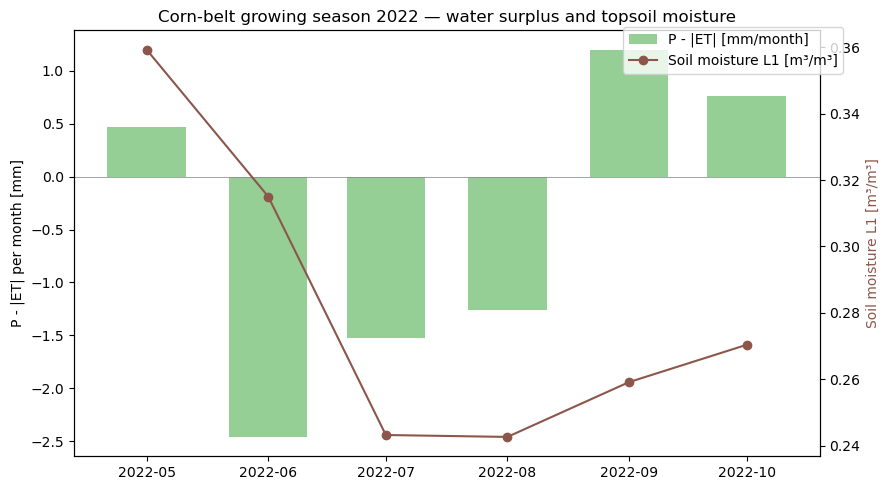

In [4]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(months, precip - et, width=20, color="tab:green", alpha=0.5, label="P - |ET| [mm/month]")
ax1.set_ylabel("P - |ET| per month [mm]")
ax1.axhline(0, color="gray", lw=0.5)

ax2 = ax1.twinx()
ax2.plot(months, soil_moisture, marker="o", color="tab:brown", label="Soil moisture L1 [m³/m³]")
ax2.set_ylabel("Soil moisture L1 [m³/m³]", color="tab:brown")

ax1.set_title("Corn-belt growing season 2022 — water surplus and topsoil moisture")
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

## Notes

- **`reanalysis-era5-land`** is the ERA5 land-surface reanalysis at
  0.1° resolution — the right product for agronomic studies. ERA5
  single-levels lives at 0.25° and runs the same land scheme but with
  coarser surface fields.
- **Reference ET ($ET_0$).** ERA5 reports actual evaporation
  (model-computed). For Penman–Monteith $ET_0$, retrieve
  `surface-net-solar-radiation`, `2m-dewpoint-temperature`,
  `10m-wind-speed`, `surface-pressure` and run FAO-56 yourself; CDS
  doesn't expose $ET_0$ directly.
- **Volumetric soil moisture layers.** Layer 1 is 0–7 cm; layers 2/3/4
  are 7–28, 28–100, 100–289 cm. Pull all four for a root-zone profile.
- **Cell size.** This notebook passes `cell_size=0.1` (ERA5-Land
  native) on both `Earthly` and `AggregationConfig` so the GeoTIFFs
  carry the right pixel-size tag in their metadata.